# Stance Detection
##  Comprehensive Comparison: AraBERT | ALLaM | LLaMA 3.1 | LoRA

| النموذج | النوع |
|---|---|
| AraBERT (Baseline) | Frozen Embeddings + Logistic Regression |
| AraBERT (Fine-tuned) | Full Fine-tuning للتصنيف |
| ALLaM 7B (0/1/3-shot) | Constrained Decoding |
| LLaMA 3.1 8B (0/1/3-shot) | Constrained Decoding |
| LoRA-ALLaM | Sequence Classification (Matched with AraBERT) |


## Data & Libraries

In [ ]:
!pip install -q transformers datasets peft accelerate bitsandbytes huggingface_hub scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.4 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata

import os, gc, warnings, random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from transformers import logging as transformers_logging
from huggingface_hub import login
from sklearn.metrics import (f1_score, accuracy_score,
                              classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
transformers_logging.set_verbosity_error()
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ─── إعدادات المشروع ───

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
SEED     = 42

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

CSV_PATH  = "/content/final_with_majority_vote_UTF8.csv"
TEXT_COL  = "text"
LABEL_COL = "Final_Label"

df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df = df[[TEXT_COL, LABEL_COL]].dropna()
df[TEXT_COL]  = df[TEXT_COL].astype(str).str.strip()
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()

# توحيد التسميات: Pos / Neg / Nat
df[LABEL_COL] = df[LABEL_COL].replace({
    'pos': 'Pos', 'neg': 'Neg', 'nat': 'Nat',
    'POS': 'Pos', 'NEG': 'Neg', 'NAT': 'Nat',
})
df = df[df[LABEL_COL].isin(['Pos', 'Neg', 'Nat'])].copy().reset_index(drop=True)

print(f"✅ عدد التغريدات: {len(df)}")
print(df[LABEL_COL].value_counts())

# dict مشترك لحفظ نتائج كل النماذج
ALL_RESULTS = {}   # {model_name: {'y_true': [...], 'y_pred': [...]}}

✅ عدد التغريدات: 1348
Final_Label
Neg    610
Pos    555
Nat    183
Name: count, dtype: int64


##  **AraBERT — Baseline**

In [ ]:
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression

ARABERT_MODEL = "aubmindlab/bert-base-arabertv02"
BERT_MAX_LEN  = 128
BERT_BATCH    = 16

label2id_bert = {"Pos": 0, "Neg": 1, "Nat": 2}
id2label_bert = {v: k for k, v in label2id_bert.items()}

y_bert = df[LABEL_COL].map(label2id_bert).to_numpy()
texts  = df[TEXT_COL].to_numpy()

# تحميل AraBERT مجمّد
tokenizer_bert = AutoTokenizer.from_pretrained(ARABERT_MODEL)
bert_encoder   = AutoModel.from_pretrained(ARABERT_MODEL).to(DEVICE)
bert_encoder.eval()

@torch.no_grad()
def embed_texts(texts, batch_size=16, max_len=128):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i+batch_size])
        enc = tokenizer_bert(batch, padding=True, truncation=True,
                             max_length=max_len, return_tensors="pt").to(DEVICE)
        out = bert_encoder(**enc)
        mask = enc["attention_mask"].unsqueeze(-1)
        mean_pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1)
        all_embs.append(mean_pooled.float().cpu().numpy())
    return np.vstack(all_embs)

print("⏳ حساب التمثيلات (embeddings)...")
X_emb = embed_texts(texts, batch_size=BERT_BATCH, max_len=BERT_MAX_LEN)
print(f"✅ Embeddings shape: {X_emb.shape}")

clf_lr = LogisticRegression(max_iter=5000, class_weight="balanced", C=0.2, random_state=SEED)
clf_lr.fit(X_emb, y_bert)
y_pred_baseline = clf_lr.predict(X_emb)

pred_labels_baseline = [id2label_bert[i] for i in y_pred_baseline]
ALL_RESULTS["AraBERT-Baseline"] = {
    'y_true': df[LABEL_COL].tolist(),
    'y_pred': pred_labels_baseline
}

f1  = f1_score(y_bert, y_pred_baseline, average='macro', zero_division=0)
acc = accuracy_score(y_bert, y_pred_baseline)
print(f"\n📊 AraBERT Baseline | F1-Macro={f1:.4f} | Accuracy={acc:.4f}")
print(classification_report(y_bert, y_pred_baseline,
      target_names=["Pos","Neg","Nat"], zero_division=0))

# حفظ ملف النتائج
out_df = df.copy()
out_df["arabert_baseline_pred"] = pred_labels_baseline
out_df.to_csv(f"arabert_baseline_results.csv",
              index=False, encoding="utf-8-sig")

del bert_encoder; torch.cuda.empty_cache(); gc.collect()

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

⏳ حساب التمثيلات (embeddings)...
✅ Embeddings shape: (1348, 768)

📊 AraBERT Baseline | F1-Macro=0.9323 | Accuracy=0.9384
              precision    recall  f1-score   support

         Pos       0.97      0.92      0.94       555
         Neg       0.95      0.94      0.94       610
         Nat       0.84      0.99      0.91       183

    accuracy                           0.94      1348
   macro avg       0.92      0.95      0.93      1348
weighted avg       0.94      0.94      0.94      1348



219

##  **AraBERT — Fine-tuned**

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)

BERT_FT_EPOCHS = 5
BERT_FT_LR     = 2e-5
BERT_FT_BATCH  = 16
WARMUP_RATIO   = 0.1

y_ft = df[LABEL_COL].map(label2id_bert).to_numpy()

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.data = list(zip(texts, labels))
        self.tokenizer, self.max_len = tokenizer, max_len

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        text, label = self.data[idx]
        enc = self.tokenizer(str(text), truncation=True, padding="max_length",
                             max_length=self.max_len, return_tensors="pt")
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(int(label), dtype=torch.long)
        }

tokenizer_ft  = AutoTokenizer.from_pretrained(ARABERT_MODEL)
train_dataset = TextDataset(df[TEXT_COL].values, y_ft, tokenizer_ft, BERT_MAX_LEN)
train_loader  = DataLoader(train_dataset, batch_size=BERT_FT_BATCH, shuffle=True)

# أوزان الفئات لمعالجة الـ imbalance
counts  = np.bincount(y_ft, minlength=3)
weights = (1.0 / np.maximum(counts, 1))
weights /= weights.sum()
weights_t = torch.tensor(weights, dtype=torch.float, device=DEVICE)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights_t)

model_ft = AutoModelForSequenceClassification.from_pretrained(
    ARABERT_MODEL, num_labels=3,
    id2label=id2label_bert, label2id=label2id_bert
).to(DEVICE)

optimizer  = AdamW(model_ft.parameters(), lr=BERT_FT_LR)
total_steps = len(train_loader) * BERT_FT_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

print(f"بدء التدريب: {BERT_FT_EPOCHS} epochs × {len(train_loader)} batches")
for epoch in range(BERT_FT_EPOCHS):
    model_ft.train()
    total_loss = 0.0
    for batch in train_loader:
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        labs  = batch["labels"].to(DEVICE)
        optimizer.zero_grad()
        out  = model_ft(input_ids=ids, attention_mask=mask)
        loss = loss_fn(out.logits, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ft.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # تقييم in-sample
    model_ft.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for batch in DataLoader(train_dataset, batch_size=BERT_FT_BATCH):
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            out  = model_ft(input_ids=ids, attention_mask=mask)
            all_p.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            all_l.extend(batch["labels"].numpy())

    f1_ep  = f1_score(all_l, all_p, average='macro', zero_division=0)
    acc_ep = accuracy_score(all_l, all_p)
    print(f"Epoch {epoch+1}/{BERT_FT_EPOCHS} | Loss={avg_loss:.4f} | F1={f1_ep:.4f} | Acc={acc_ep:.4f}")

all_preds_ft = all_p
pred_labels_ft = [id2label_bert[i] for i in all_preds_ft]
ALL_RESULTS["AraBERT-FT"] = {
    'y_true': df[LABEL_COL].tolist(),
    'y_pred': pred_labels_ft
}

print(f"\n AraBERT Fine-tuned | F1={f1_ep:.4f} | Acc={acc_ep:.4f}")
print(classification_report(all_l, all_preds_ft,
      target_names=["Pos","Neg","Nat"], zero_division=0))

# حفظ النموذج والنتائج
model_ft.save_pretrained(f"arabert_finetuned_model")
tokenizer_ft.save_pretrained(f"arabert_finetuned_model")

out_df = df.copy()
out_df["arabert_finetuned_pred"] = pred_labels_ft
out_df.to_csv(f"arabert_finetuned_results.csv",
              index=False, encoding="utf-8-sig")

del model_ft; torch.cuda.empty_cache(); gc.collect()
print("تم حفظ النموذج والنتائج")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

بدء التدريب: 5 epochs × 85 batches
Epoch 1/5 | Loss=1.0391 | F1=0.5543 | Acc=0.5623
Epoch 2/5 | Loss=0.7986 | F1=0.7729 | Acc=0.7975
Epoch 3/5 | Loss=0.5684 | F1=0.8720 | Acc=0.8843
Epoch 4/5 | Loss=0.3880 | F1=0.9203 | Acc=0.9266
Epoch 5/5 | Loss=0.2974 | F1=0.9228 | Acc=0.9325

 AraBERT Fine-tuned | F1=0.9228 | Acc=0.9325
              precision    recall  f1-score   support

         Pos       0.95      0.95      0.95       555
         Neg       0.96      0.90      0.93       610
         Nat       0.81      0.98      0.89       183

    accuracy                           0.93      1348
   macro avg       0.91      0.94      0.92      1348
weighted avg       0.94      0.93      0.93      1348



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

تم حفظ النموذج والنتائج


## **Settings For Allam & Lallama**

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from tqdm.auto import tqdm

MODELS_TO_RUN = {
    "allam": "allam-ai/ALLaM-7B-Instruct-preview",
    "llama": "meta-llama/Llama-3.1-8B-Instruct"
}

LABEL_MAP    = {"Pos": "إيجابي", "Neg": "سلبي", "Nat": "محايد"}
REVERSE_MAP  = {v: k for k, v in LABEL_MAP.items()}
ARABIC_LABELS = list(LABEL_MAP.values())

def verify_single_tokens(tokenizer, model_name):
    print(f"\n🔍 التحقق من التوكنات ({model_name}):")
    for orig, arabic in LABEL_MAP.items():
        ids = tokenizer(arabic, add_special_tokens=False)['input_ids']
        print(f"  {orig} → '{arabic}' → {ids} → First token ID: {ids[0]}")

def predict_constrained(model, tokenizer, prompt):
    """Constrained Decoding: يختار الأعلى logit للكلمات"""
    inputs    = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
        logits  = outputs.logits[0, -1, :]
    return REVERSE_MAP[max(
        ARABIC_LABELS,
        key=lambda lab: logits[
            tokenizer(lab, add_special_tokens=False)['input_ids'][0]
        ].item()
    )]

def build_allam_prompt(text, shots=0):
    header = (
        "أنت خبير تحليل مشاعر. صنّف التغريدة التالية.\n"
        "الإجابة يجب أن تكون كلمة واحدة فقط: إيجابي، سلبي، أو محايد.\n\n"
    )
    examples = [
        ("المرأة السعودية أبدعت في المحافل الرياضية.", "إيجابي"),
        ("لا أقبل ممارسة النساء للرياضة في الأماكن العامة.", "سلبي"),
        ("هناك نقاشات حول مستقبل الرياضة النسائية.", "محايد"),
    ]
    ex_text = "".join(f"النص: {t}\nالتصنيف: {l}\n\n"
                      for t, l in examples[:shots])
    return header + ex_text + f"النص: {text}\nالتصنيف: "

def build_llama_prompt(tokenizer, text, shots=0):
    system = ("أنت خبير تحليل مشاعر. صنّف التغريدة التالية.\n"
              "الإجابة يجب أن تكون كلمة واحدة فقط: إيجابي، سلبي، أو محايد.")
    examples = [
        ("المرأة السعودية أبدعت في المحافل الرياضية.", "إيجابي"),
        ("لا أقبل ممارسة النساء للرياضة في الأماكن العامة.", "سلبي"),
        ("هناك نقاشات حول مستقبل الرياضة النسائية.", "محايد"),
    ]
    messages = [{"role": "system", "content": system}]
    for t, l in examples[:shots]:
        messages += [{"role": "user",      "content": f"النص: {t}"},
                     {"role": "assistant", "content": l}]
    messages.append({"role": "user", "content": f"النص: {text}"})
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)

def run_llm_inference(model_id, model_name):
    print(f"\n{'='*55}\n تجهيز: {model_name.upper()}\n{'='*55}")

    tokenizer = AutoTokenizer.from_pretrained(model_id, token=HF_TOKEN)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    verify_single_tokens(tokenizer, model_name)

    model = AutoModelForCausalLM.from_pretrained(
        model_id, token=HF_TOKEN, device_map="auto",
        quantization_config=BitsAndBytesConfig(load_in_4bit=True),
        torch_dtype=torch.float16
    ).eval()

    for shots in [0, 1, 3]:
        preds = []
        for text in tqdm(df[TEXT_COL], desc=f"{model_name} ({shots}-shot)"):
            prompt = (build_allam_prompt(text, shots=shots)
                      if model_name == "allam"
                      else build_llama_prompt(tokenizer, text, shots=shots))
            preds.append(predict_constrained(model, tokenizer, prompt))

        key = f"{model_name.upper()}-{shots}shot"
        ALL_RESULTS[key] = {
            'y_true': df[LABEL_COL].tolist(),
            'y_pred': preds
        }
        y_true = df[LABEL_COL].tolist()
        f1  = f1_score(y_true, preds, average='macro', zero_division=0)
        acc = accuracy_score(y_true, preds)
        dist = pd.Series(preds).value_counts().to_dict()
        print(f" {key} | F1={f1:.4f} | Acc={acc:.4f} | {dist}")
        print(classification_report(y_true, preds, zero_division=0))

        # حفظ الملف
        out_df = df.copy()
        out_df[f"{model_name}_{shots}shot_pred"] = preds
        out_df.to_csv(f"{model_name}_{shots}shot_results.csv",
                      index=False, encoding="utf-8-sig")

    del model; torch.cuda.empty_cache(); gc.collect()


##  **ALLaM 7B — Zero/One/Three-Shot**

In [ ]:
run_llm_inference(MODELS_TO_RUN["allam"], "allam")


 تجهيز: ALLAM


config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/1.23M [00:00<?, ?B/s]


🔍 التحقق من التوكنات (allam):
  Pos → 'إيجابي' → [63673, 1301, 3081] → First token ID: 63673
  Neg → 'سلبي' → [1857, 389] → First token ID: 1857
  Nat → 'محايد' → [8245, 22960] → First token ID: 8245


...

 ALLAM-0shot | F1=0.3791 | Acc=0.5401 | {'Pos': 959, 'Neg': 389}
              precision    recall  f1-score   support

         Nat       0.00      0.00      0.00       183
         Neg       0.66      0.42      0.52       610
         Pos       0.49      0.85      0.62       555

    accuracy                           0.54      1348
   macro avg       0.38      0.42      0.38      1348
weighted avg       0.50      0.54      0.49      1348



allam (1-shot):   0%|          | 0/1348 [00:00<?, ?it/s]

 ALLAM-1shot | F1=0.3232 | Acc=0.4926 | {'Pos': 1141, 'Neg': 207}
              precision    recall  f1-score   support

         Nat       0.00      0.00      0.00       183
         Neg       0.71      0.24      0.36       610
         Pos       0.45      0.93      0.61       555

    accuracy                           0.49      1348
   macro avg       0.39      0.39      0.32      1348
weighted avg       0.51      0.49      0.41      1348



allam (3-shot):   0%|          | 0/1348 [00:00<?, ?it/s]

 ALLAM-3shot | F1=0.3435 | Acc=0.5030 | {'Pos': 1122, 'Neg': 219, 'Nat': 7}
              precision    recall  f1-score   support

         Nat       0.43      0.02      0.03       183
         Neg       0.73      0.26      0.38       610
         Pos       0.46      0.93      0.62       555

    accuracy                           0.50      1348
   macro avg       0.54      0.40      0.34      1348
weighted avg       0.58      0.50      0.43      1348



## **LLaMA 3.1 8B — Zero/One/Three-Shot**

In [ ]:
run_llm_inference(MODELS_TO_RUN["llama"], "llama")


 تجهيز: LLAMA


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

 LLAMA-0shot | F1=0.2527 | Acc=0.4266 | {'Pos': 1265, 'Neg': 59, 'Nat': 24}
              precision    recall  f1-score   support

         Nat       0.29      0.04      0.07       183
         Neg       0.59      0.06      0.10       610
         Pos       0.42      0.96      0.59       555

    accuracy                           0.43      1348
   macro avg       0.44      0.35      0.25      1348
weighted avg       0.48      0.43      0.30      1348



llama (1-shot):   0%|          | 0/1348 [00:00<?, ?it/s]

 LLAMA-1shot | F1=0.5465 | Acc=0.6558 | {'Neg': 891, 'Pos': 351, 'Nat': 106}
              precision    recall  f1-score   support

         Nat       0.33      0.19      0.24       183
         Neg       0.61      0.89      0.73       610
         Pos       0.87      0.55      0.67       555

    accuracy                           0.66      1348
   macro avg       0.60      0.54      0.55      1348
weighted avg       0.68      0.66      0.64      1348



llama (3-shot):   0%|          | 0/1348 [00:00<?, ?it/s]

 LLAMA-3shot | F1=0.5800 | Acc=0.6543 | {'Neg': 636, 'Pos': 528, 'Nat': 184}
              precision    recall  f1-score   support

         Nat       0.33      0.33      0.33       183
         Neg       0.68      0.71      0.70       610
         Pos       0.73      0.70      0.72       555

    accuracy                           0.65      1348
   macro avg       0.58      0.58      0.58      1348
weighted avg       0.66      0.65      0.65      1348



## **LoRA Fine-tuning على ALLaM**

In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification
from torch.utils.data import Dataset as TorchDataset
from sklearn.model_selection import train_test_split
import os

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
print("\n=== تدريب LoRA-ALLaM (Sequence Classification) ===")

model_id  = MODELS_TO_RUN["allam"]
tok_lora  = AutoTokenizer.from_pretrained(model_id, token=HF_TOKEN)
if tok_lora.pad_token is None:
    tok_lora.pad_token = tok_lora.eos_token

y_ft_lora = df[LABEL_COL].map(label2id_bert).to_numpy()

class LoraTextDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.data = list(zip(texts, labels))
        self.tokenizer, self.max_len = tokenizer, max_len

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        text, label = self.data[idx]
        enc = self.tokenizer(str(text), truncation=True, padding="max_length",
                             max_length=self.max_len, return_tensors="pt")
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(int(label), dtype=torch.long)
        }

train_dataset = LoraTextDataset(df[TEXT_COL].values, y_ft_lora, tok_lora, BERT_MAX_LEN)
print(f"Dataset size: {len(train_dataset)}")

torch.cuda.empty_cache(); gc.collect()

model_lora = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=3,
    id2label=id2label_bert,
    label2id=label2id_bert,
    device_map="auto",
    quantization_config=BitsAndBytesConfig(load_in_4bit=True),
    token=HF_TOKEN
)
model_lora.config.pad_token_id = tok_lora.pad_token_id

model_lora = prepare_model_for_kbit_training(model_lora)

lora_config = LoraConfig(
    r=32, lora_alpha=64,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05, bias="none", task_type="SEQ_CLS"
)
model_lora = get_peft_model(model_lora, lora_config)
model_lora.print_trainable_parameters()

counts  = np.bincount(y_ft_lora, minlength=3)
weights = (1.0 / np.maximum(counts, 1))
weights /= weights.sum()

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float, device=model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir=f"lora_allam",
    num_train_epochs=BERT_FT_EPOCHS,
    per_device_train_batch_size=BERT_FT_BATCH,
    gradient_accumulation_steps=1,
    learning_rate=2e-4,
    warmup_ratio=WARMUP_RATIO,
    logging_steps=30,
    save_strategy="no",
    fp16=True, report_to="none"
)

trainer = CustomTrainer(
    model=model_lora,
    args=training_args,
    train_dataset=train_dataset,
)
trainer.train()

# ── الاستدلال ──
model_lora.eval()
lora_preds = []

test_loader = DataLoader(train_dataset, batch_size=BERT_FT_BATCH)
with torch.no_grad():
    for batch in tqdm(test_loader, desc="LoRA-ALLaM Inference"):
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        out = model_lora(input_ids=ids, attention_mask=mask)
        lora_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())

lora_preds_labels = [id2label_bert[i] for i in lora_preds]

ALL_RESULTS["LoRA-ALLaM"] = {
    'y_true': df[LABEL_COL].tolist(),
    'y_pred': lora_preds_labels
}

y_true = df[LABEL_COL].tolist()
f1  = f1_score(y_true, lora_preds_labels, average='macro', zero_division=0)
acc = accuracy_score(y_true, lora_preds_labels)
print(f"\n LoRA-ALLaM | F1={f1:.4f} | Acc={acc:.4f}")
print(classification_report(y_true, lora_preds_labels, zero_division=0))

out_df = df.copy()
out_df["lora_allam_pred"] = lora_preds_labels
out_df.to_csv(f"lora_allam_results.csv",
              index=False, encoding="utf-8-sig")

# حفظ أوزان LoRA
model_lora.save_pretrained(f"lora_allam_weights")

del model_lora; torch.cuda.empty_cache(); gc.collect()
print("✅ تم حفظ نتائج وأوزان LoRA-ALLaM")



=== تدريب LoRA-ALLaM (Sequence Classification) ===
Dataset size: 1348


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 33,566,720 || all params: 6,771,994,624 || trainable%: 0.4957
{'loss': '1.561', 'grad_norm': '111.9', 'learning_rate': '0.0001349', 'epoch': '0.3529'}
{'loss': '1.261', 'grad_norm': '106.4', 'learning_rate': '0.0001916', 'epoch': '0.7059'}
{'loss': '1.302', 'grad_norm': '154.9', 'learning_rate': '0.0001759', 'epoch': '1.059'}
{'loss': '1.189', 'grad_norm': '70.57', 'learning_rate': '0.0001602', 'epoch': '1.412'}
{'loss': '1.189', 'grad_norm': '139.9', 'learning_rate': '0.0001445', 'epoch': '1.765'}
{'loss': '1.039', 'grad_norm': '37.42', 'learning_rate': '0.0001288', 'epoch': '2.118'}
{'loss': '1.03', 'grad_norm': '36.79', 'learning_rate': '0.0001131', 'epoch': '2.471'}
{'loss': '0.9772', 'grad_norm': '88.66', 'learning_rate': '9.738e-05', 'epoch': '2.824'}
{'loss': '0.9085', 'grad_norm': '94.28', 'learning_rate': '8.168e-05', 'epoch': '3.176'}
{'loss': '0.7611', 'grad_norm': '17.58', 'learning_rate': '6.597e-05', 'epoch': '3.529'}
{'loss': '0.7162', 'grad_norm': '58.

LoRA-ALLaM Inference:   0%|          | 0/85 [00:00<?, ?it/s]


 LoRA-ALLaM | F1=0.9125 | Acc=0.9191
              precision    recall  f1-score   support

         Nat       0.83      0.96      0.89       183
         Neg       0.94      0.91      0.93       610
         Pos       0.94      0.91      0.92       555

    accuracy                           0.92      1348
   macro avg       0.90      0.93      0.91      1348
weighted avg       0.92      0.92      0.92      1348

✅ تم حفظ نتائج وأوزان LoRA-ALLaM


## **Confusion Matrice**

In [ ]:
LABELS_ORDER = ['Pos', 'Neg', 'Nat']

summary_rows = []
for model_name, res in ALL_RESULTS.items():
    y_true = res['y_true']
    y_pred = res['y_pred']

    f1_macro  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_pos    = f1_score(y_true, y_pred, labels=['Pos'], average='macro', zero_division=0)
    f1_neg    = f1_score(y_true, y_pred, labels=['Neg'], average='macro', zero_division=0)
    f1_nat    = f1_score(y_true, y_pred, labels=['Nat'], average='macro', zero_division=0)
    acc       = accuracy_score(y_true, y_pred)

    summary_rows.append({
        'الموديل':   model_name,
        'F1-Macro':  round(f1_macro, 4),
        'F1-Pos':    round(f1_pos,   4),
        'F1-Neg':    round(f1_neg,   4),
        'F1-Nat':    round(f1_nat,   4),
        'Accuracy':  round(acc,      4),
    })

results_df = pd.DataFrame(summary_rows).sort_values('F1-Macro', ascending=False).reset_index(drop=True)
results_df.index += 1

print("\n" + "="*70)
print("               📊 النتائج النهائية المقارنة")
print("="*70)
print(results_df.to_string())

results_df.to_csv(f"final_comparison_all_models.csv",
                  index=False, encoding="utf-8-sig")
print(f"\n تم حفظ جدول المقارنة في: final_comparison_all_models.csv")


               📊 النتائج النهائية المقارنة
            الموديل  F1-Macro  F1-Pos  F1-Neg  F1-Nat  Accuracy
1  AraBERT-Baseline    0.9323  0.9435  0.9433  0.9100    0.9384
2        AraBERT-FT    0.9228  0.9503  0.9315  0.8867    0.9325
3        LoRA-ALLaM    0.9125  0.9232  0.9254  0.8889    0.9191
4       LLAMA-3shot    0.5800  0.7165  0.6966  0.3270    0.6543
5       LLAMA-1shot    0.5465  0.6711  0.7262  0.2422    0.6558
6       ALLAM-0shot    0.3791  0.6209  0.5165  0.0000    0.5401
7       ALLAM-3shot    0.3435  0.6154  0.3836  0.0316    0.5030
8       ALLAM-1shot    0.3232  0.6097  0.3599  0.0000    0.4926
9       LLAMA-0shot    0.2527  0.5857  0.1046  0.0676    0.4266

 تم حفظ جدول المقارنة في: final_comparison_all_models.csv


## **visualize**

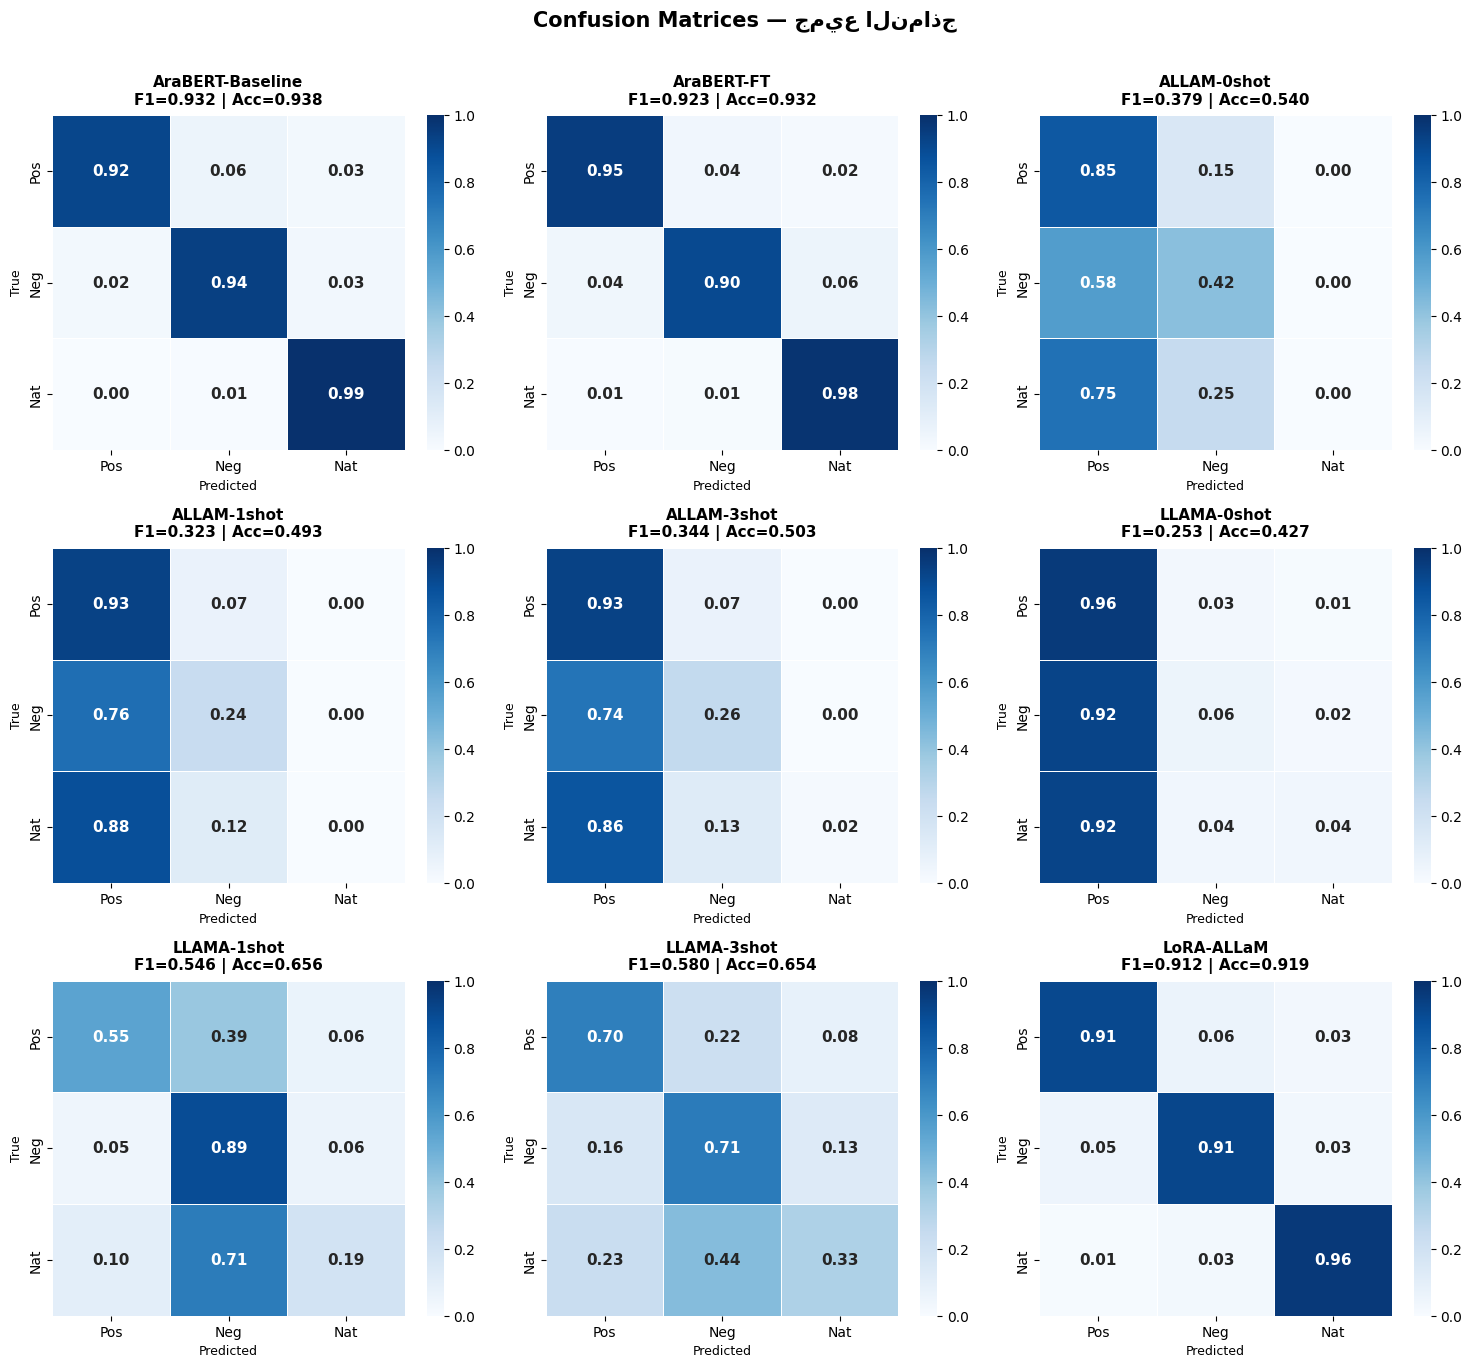

تم حفظ Confusion Matrices


In [ ]:
n_models = len(ALL_RESULTS)
n_cols   = 3
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5, n_rows * 4.5))
axes_flat = axes.flatten() if n_models > 1 else [axes]

for ax, (model_name, res) in zip(axes_flat, ALL_RESULTS.items()):
    y_true = res['y_true']
    y_pred = res['y_pred']

    cm = confusion_matrix(y_true, y_pred, labels=LABELS_ORDER)
    # normalize
    cm_norm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sums > 0, cm / row_sums, 0)

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=LABELS_ORDER, yticklabels=LABELS_ORDER,
                ax=ax, vmin=0, vmax=1, linewidths=0.5,
                annot_kws={"size": 11, "weight": "bold"})

    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f"{model_name}\nF1={f1:.3f} | Acc={acc:.3f}",
                 fontsize=11, weight='bold', pad=8)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)

# إخفاء المحاور الفارغة
for ax in axes_flat[len(ALL_RESULTS):]:
    ax.set_visible(False)

plt.suptitle("Confusion Matrices — جميع النماذج", fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"confusion_matrices_all.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("تم حفظ Confusion Matrices")

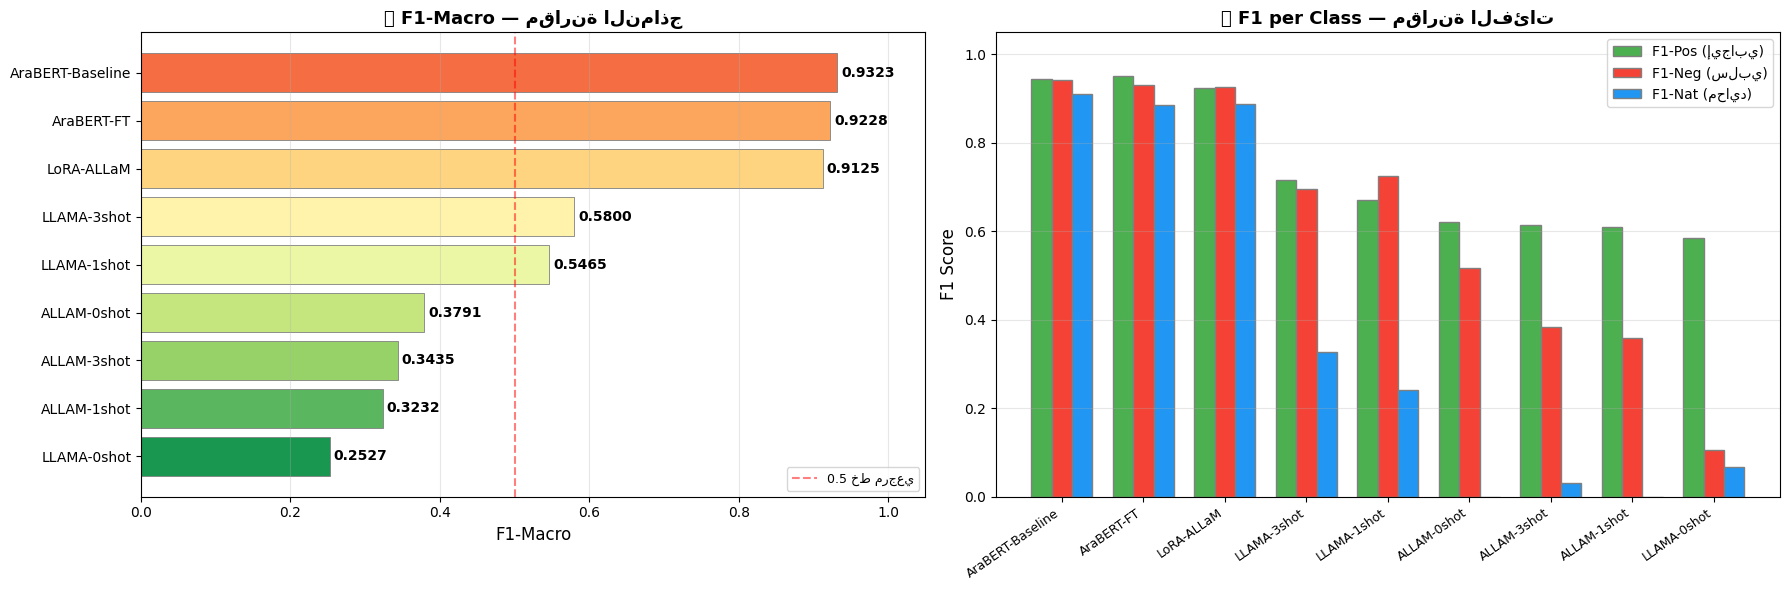

تم حفظ الرسوم البيانية


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ─── Bar chart F1-Macro ───
colors = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(results_df))[::-1]
)
bars = axes[0].barh(results_df['الموديل'][::-1],
                    results_df['F1-Macro'][::-1],
                    color=colors, edgecolor='grey', linewidth=0.6)

for bar, val in zip(bars, results_df['F1-Macro'][::-1]):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10, weight='bold')

axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel('F1-Macro', fontsize=12)
axes[0].set_title('📊 F1-Macro — مقارنة النماذج', fontsize=13, weight='bold')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='0.5 خط مرجعي')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# ─── Per-class F1 grouped ───
x = np.arange(len(results_df))
w = 0.25
axes[1].bar(x - w, results_df['F1-Pos'], w, label='F1-Pos (إيجابي)', color='#4CAF50', edgecolor='grey')
axes[1].bar(x, results_df['F1-Neg'], w, label='F1-Neg (سلبي)', color='#F44336', edgecolor='grey')
axes[1].bar(x + w, results_df['F1-Nat'], w, label='F1-Nat (محايد)', color='#2196F3', edgecolor='grey')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['الموديل'], rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].set_title('📊 F1 per Class — مقارنة الفئات', fontsize=13, weight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"f1_comparison_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("تم حفظ الرسوم البيانية")

In [ ]:
print("\n" + "="*65)
print(" 🏆 أفضل نموذج:")
best = results_df.iloc[0]
print(f"   {best['الموديل']}")
print(f"   F1-Macro = {best['F1-Macro']:.4f}")
print(f"   Accuracy = {best['Accuracy']:.4f}")
print("="*65 + "\n")

print("📁 الملفات المحفوظة:")
print("  ✅ arabert_baseline_results.csv")
print("  ✅ arabert_finetuned_results.csv")
print("  ✅ final_comparison_all_models.csv")
print("  ✅ confusion_matrices_all.png")
print("  ✅ f1_comparison_chart.png")


 🏆 أفضل نموذج:
   AraBERT-Baseline
   F1-Macro = 0.9323
   Accuracy = 0.9384

📁 الملفات المحفوظة:
  ✅ arabert_baseline_results.csv
  ✅ arabert_finetuned_results.csv
  ✅ final_comparison_all_models.csv
  ✅ confusion_matrices_all.png
  ✅ f1_comparison_chart.png
